# Aristos lens backtest

Runs the real Aristos lenses over the last 10 years on your watched cohorts and writes one CSV per cohort and lens.

**Before you start, put two things on your Google Drive** (from your PC's repo folder):

1. Copy the folder `data\local\cohorts` to `MyDrive/aristos/cohorts` (it holds the frozen member lists, which are not in GitHub).
2. The file `data\local\cohorts\watch.yaml` will come with it; the notebook reads the 13 watched cohort names from there.

Then run the cells top to bottom. The run takes hours; results are saved as they finish, so you can stop and rerun and it carries on where it left off.

In [1]:
#@title 1. Get the code and install it
BRANCH = "main"  #@param {type:"string"}
# If backtest.py (or whatever you're testing) is not on main yet, change BRANCH to the PR's
# branch name instead.
import os, subprocess, sys
if not os.path.exists("/content/aristos-council"):
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH,
                    "https://github.com/kayvonsalari/aristos-council"], check=True, cwd="/content")
else:
    subprocess.run(["git", "pull"], cwd="/content/aristos-council")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "/content/aristos-council"], check=True)
os.chdir("/content/aristos-council")
print("code ready, branch", BRANCH)

code ready, branch main


In [2]:
#@title 2. Connect Google Drive (cohorts in, results and cache out)
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
import glob, os

DRIVE = "/content/drive/MyDrive/aristos"
OUT = f"{DRIVE}/backtests"                 # the CSVs land here
CACHE = f"{DRIVE}/aristos_cache"           # so a second run is fast and free
os.makedirs(OUT, exist_ok=True); os.makedirs(CACHE, exist_ok=True)

# Find your copy of data/local/cohorts (it holds watch.yaml, which is not in GitHub) wherever it
# sits on the Drive, instead of requiring one fixed path.
candidates = [p for p in glob.glob("/content/drive/MyDrive/**/watch.yaml", recursive=True)
             if "cohorts" in p.replace(os.sep, "/").lower()]
assert candidates, ("no watch.yaml found under MyDrive with 'cohorts' in its path — copy "
                   "data/local/cohorts (it comes with watch.yaml) to your Drive first")
COHORTS_ROOT = os.path.dirname(sorted(candidates)[0])
print("COHORTS_ROOT ->", COHORTS_ROOT)

# the code caches under .aristos_cache in its own folder; point that at Drive
if os.path.islink(".aristos_cache") or os.path.exists(".aristos_cache"):
    import shutil; shutil.rmtree(".aristos_cache", ignore_errors=True)
    if os.path.islink(".aristos_cache"): os.unlink(".aristos_cache")
os.symlink(CACHE, ".aristos_cache")
print("drive ready")

Mounted at /content/drive
COHORTS_ROOT -> /content/drive/MyDrive/Aristos/cohorts/cohorts
drive ready


In [3]:
#@title 3. Your EODHD key (typed, never saved in the notebook)
import os
from getpass import getpass
os.environ["EODHD_API_KEY"] = getpass("EODHD API key: ").strip()
print("key set" if os.environ["EODHD_API_KEY"] else "NO KEY")

EODHD API key: ··········
key set


In [4]:
#@title 4. What to test: the watched cohorts and the voting stock lenses
import yaml
watched = yaml.safe_load(open(f"{COHORTS_ROOT}/watch.yaml"))["watch"]

# Explicit, not auto-detected from strategies/*.yaml: an ETF lens (its factors don't mean the
# same thing for a fund), a screen LENS (criteria:-shaped, not a rank strategy) or a CHECK lens
# (marks, does not vote — e.g. forensic_v1) must never be backtested here. Edit this list to test
# a subset or add a lens.
LENSES = ["magic_formula_raw_v1", "magic_formula_momentum_v1", "growth_garp_v2",
         "conservative_plus_v1", "cyclical_income_v1"]

print(len(watched), "cohorts:"); [print("  ", c) for c in watched]
print("\n", len(LENSES), "voting stock lenses:"); [print("  ", l) for l in LENSES]
print(f"\n{len(watched)} cohorts x {len(LENSES)} lenses = {len(watched) * len(LENSES)} runs")

13 cohorts:
   Comms - Interactive Media & Gaming
   Tech - Systems Software
   Comms - Media & Entertainment
   Industrials - Grid & Electrical Machinery
   Tech - Semiconductor Equipment
   Tech - IT Services
   Health - Medical Devices & Instruments
   Health - Large Pharma
   Industrials - Airlines & Airports
   Consumer - Auto Manufacturers
   Tech - Hardware
   Materials - Diversified Mining
   Tech - Semiconductors

 5 voting stock lenses:
   magic_formula_raw_v1
   magic_formula_momentum_v1
   growth_garp_v2
   conservative_plus_v1
   cyclical_income_v1

13 cohorts x 5 lenses = 65 runs


In [5]:
#@title 5. Run (hours; luck baseline adds ~15s/cohort-lens on a warm cache; safe to stop and rerun, finished pairs are skipped)
YEARS = 10       #@param {type:"integer"}
HOLD_MONTHS = 12 #@param {type:"integer"}
COST_BPS = 50    #@param {type:"number"}
RANDOM_BASKETS = 500  #@param {type:"integer"}
import time, traceback
from datetime import date
import sys; sys.path.insert(0, "/content/aristos-council/src")   # an editable install isn't
                                                                  # visible to an already-running
                                                                  # Colab kernel
from aristos_council.backtest import run_lens_backtest, verdict, to_csv, csv_path, cohort_slug

today = date.today()
end = date(today.year, today.month, 1)                       # last full month
start = date(end.year - YEARS, end.month, 1)
print(f"window {start} -> {end}, hold {HOLD_MONTHS} months, cost {COST_BPS} bps, "
     f"{RANDOM_BASKETS} random baskets/round (BACKTEST-1C)")

results, failures = {}, {}
for cohort in watched:
    for lens in LENSES:
        target = os.path.join(OUT, cohort_slug(cohort), f"{lens}.csv")
        if os.path.exists(target):
            print(f"skip (done): {cohort} x {lens}"); continue
        t0 = time.time()
        print(f"\n=== {cohort} x {lens}")
        try:
            r = run_lens_backtest(cohort, lens, start=start, end=end, hold_months=HOLD_MONTHS,
                                  cost_bps=COST_BPS, cohorts_root=COHORTS_ROOT,
                                  random_baskets=RANDOM_BASKETS,
                                  progress=lambda m: print("   ", m))
            path = to_csv(r, OUT)
            results[(cohort, lens)] = r
            print(f"    -> {verdict(r)} | {path} | {time.time()-t0:.0f}s")
        except Exception as exc:
            failures[(cohort, lens)] = f"{type(exc).__name__}: {exc}"
            print("    FAILED:", failures[(cohort, lens)]); traceback.print_exc(limit=2)
print("\ndone.", len(results), "new results,", len(failures), "failures")
for k, v in failures.items(): print("  ", k, v)

Streaming output truncated to the last 5000 lines.
    2025-07-31 (107/108): 37 eligible, 24 ranked, 5 BUY (1 new), excess +34.4%
    2025-08-31 (108/108): 37 eligible, 24 ranked, 5 BUY (0 new), excess +29.1%
    -> not proven | /content/drive/MyDrive/aristos/backtests/comms_interactive_media_gaming/cyclical_income_v1.csv | 11s

=== Tech - Systems Software x magic_formula_raw_v1
    2016-09-30 (1/108): 19 eligible, 15 ranked, 3 BUY (3 new), excess +11.4%
    2016-10-31 (2/108): 19 eligible, 15 ranked, 3 BUY (1 new), excess -1.6%
    2016-11-30 (3/108): 19 eligible, 15 ranked, 3 BUY (1 new), excess -18.0%
    2016-12-31 (4/108): 19 eligible, 15 ranked, 3 BUY (2 new), excess -0.5%
    2017-01-31 (5/108): 19 eligible, 15 ranked, 3 BUY (1 new), excess -9.3%
    2017-02-28 (6/108): 19 eligible, 16 ranked, 4 BUY (2 new), excess -5.1%
    2017-03-31 (7/108): 19 eligible, 16 ranked, 4 BUY (0 new), excess -12.8%
    2017-04-30 (8/108): 21 eligible, 16 ranked, 4 BUY (1 new), excess -6.6%
    201

ERROR:yfinance:$0668.HK: possibly delisted; no price data found  (1d 2014-07-23 -> 2026-08-31)


    2016-09-30 (1/108): 19 eligible, 18 ranked, 4 BUY (4 new), excess -8.3%
    2016-10-31 (2/108): 19 eligible, 18 ranked, 4 BUY (2 new), excess -21.4%
    2016-11-30 (3/108): 19 eligible, 18 ranked, 4 BUY (1 new), excess +15.3%
    2016-12-31 (4/108): 19 eligible, 18 ranked, 4 BUY (2 new), excess -13.7%
    2017-01-31 (5/108): 19 eligible, 18 ranked, 4 BUY (1 new), excess -15.4%
    2017-02-28 (6/108): 19 eligible, 18 ranked, 4 BUY (2 new), excess +24.0%
    2017-03-31 (7/108): 19 eligible, 19 ranked, 4 BUY (1 new), excess +5.1%
    2017-04-30 (8/108): 19 eligible, 19 ranked, 4 BUY (0 new), excess +7.2%
    2017-05-31 (9/108): 19 eligible, 18 ranked, 4 BUY (1 new), excess +2.8%
    2017-06-30 (10/108): 19 eligible, 18 ranked, 4 BUY (2 new), excess +15.9%
    2017-07-31 (11/108): 19 eligible, 18 ranked, 4 BUY (0 new), excess +12.5%
    2017-08-31 (12/108): 19 eligible, 18 ranked, 4 BUY (0 new), excess +12.5%
    2017-09-30 (13/108): 19 eligible, 18 ranked, 4 BUY (2 new), excess +9.1%


ERROR:yfinance:$0668.HK: possibly delisted; no price data found  (1d 2014-07-23 -> 2026-08-31)


    2016-09-30 (1/108): 19 eligible, 18 ranked, 4 BUY (4 new), excess -8.3%
    2016-10-31 (2/108): 19 eligible, 18 ranked, 4 BUY (2 new), excess -21.4%
    2016-11-30 (3/108): 19 eligible, 18 ranked, 4 BUY (1 new), excess +15.3%
    2016-12-31 (4/108): 19 eligible, 18 ranked, 4 BUY (2 new), excess -13.7%
    2017-01-31 (5/108): 19 eligible, 18 ranked, 4 BUY (1 new), excess -15.4%
    2017-02-28 (6/108): 19 eligible, 18 ranked, 4 BUY (2 new), excess +24.0%
    2017-03-31 (7/108): 19 eligible, 19 ranked, 4 BUY (1 new), excess +5.1%
    2017-04-30 (8/108): 19 eligible, 19 ranked, 4 BUY (0 new), excess +7.2%
    2017-05-31 (9/108): 19 eligible, 18 ranked, 4 BUY (1 new), excess +2.8%
    2017-06-30 (10/108): 19 eligible, 18 ranked, 4 BUY (2 new), excess +15.9%
    2017-07-31 (11/108): 19 eligible, 18 ranked, 4 BUY (0 new), excess +12.5%
    2017-08-31 (12/108): 19 eligible, 18 ranked, 4 BUY (0 new), excess +12.5%
    2017-09-30 (13/108): 19 eligible, 17 ranked, 4 BUY (1 new), excess +26.3%

...

    2016-09-30 (1/108): 19 eligible, 7 ranked, 2 BUY (2 new), no position
    2016-10-31 (2/108): 19 eligible, 7 ranked, 2 BUY (1 new), no position
    2016-11-30 (3/108): 19 eligible, 7 ranked, 2 BUY (0 new), no position
    2016-12-31 (4/108): 19 eligible, 6 ranked, 2 BUY (0 new), no position
    2017-01-31 (5/108): 19 eligible, 6 ranked, 2 BUY (0 new), no position
    2017-02-28 (6/108): 19 eligible, 6 ranked, 2 BUY (0 new), no position
    2017-03-31 (7/108): 19 eligible, 5 ranked, 1 BUY (0 new), no position
    2017-04-30 (8/108): 19 eligible, 5 ranked, 1 BUY (0 new), no position
    2017-05-31 (9/108): 19 eligible, 5 ranked, 1 BUY (0 new), no position
    2017-06-30 (10/108): 19 eligible, 5 ranked, 1 BUY (0 new), no position
    2017-07-31 (11/108): 19 eligible, 5 ranked, 1 BUY (0 new), no position
    2017-08-31 (12/108): 19 eligible, 5 ranked, 1 BUY (0 new), no position
    2017-09-30 (13/108): 19 eligible, 5 ranked, 1 BUY (0 new), no position
    2017-10-31 (14/108): 19 eligib

ERROR:yfinance:$0668.HK: possibly delisted; no price data found  (1d 2014-07-23 -> 2026-08-31)


    2016-09-30 (1/108): 19 eligible, 6 ranked, 2 BUY (2 new), no position
    2016-10-31 (2/108): 19 eligible, 5 ranked, 1 BUY (0 new), no position
    2016-11-30 (3/108): 19 eligible, 6 ranked, 2 BUY (1 new), no position
    2016-12-31 (4/108): 19 eligible, 5 ranked, 1 BUY (0 new), no position
    2017-01-31 (5/108): 19 eligible, 5 ranked, 1 BUY (0 new), no position
    2017-02-28 (6/108): 19 eligible, 5 ranked, 1 BUY (0 new), no position
    2017-03-31 (7/108): 19 eligible, 5 ranked, 1 BUY (0 new), no position
    2017-04-30 (8/108): 19 eligible, 5 ranked, 1 BUY (0 new), no position
    2017-05-31 (9/108): 19 eligible, 5 ranked, 1 BUY (0 new), no position
    2017-06-30 (10/108): 19 eligible, 5 ranked, 1 BUY (0 new), no position
    2017-07-31 (11/108): 19 eligible, 5 ranked, 1 BUY (0 new), no position
    2017-08-31 (12/108): 19 eligible, 5 ranked, 1 BUY (1 new), no position
    2017-09-30 (13/108): 19 eligible, 5 ranked, 1 BUY (1 new), no position
    2017-10-31 (14/108): 19 eligib

ERROR:yfinance:$0668.HK: possibly delisted; no price data found  (1d 2014-07-23 -> 2026-08-31)


    2025-08-31 (108/108): 38 eligible, 10 ranked, 2 BUY (0 new), no position
    -> insufficient | /content/drive/MyDrive/aristos/backtests/tech_hardware/conservative_plus_v1.csv | 11s

=== Tech - Hardware x cyclical_income_v1
    2016-09-30 (1/108): 19 eligible, 10 ranked, 2 BUY (2 new), no position
    2016-10-31 (2/108): 19 eligible, 10 ranked, 2 BUY (0 new), no position
    2016-11-30 (3/108): 19 eligible, 10 ranked, 2 BUY (0 new), no position
    2016-12-31 (4/108): 19 eligible, 10 ranked, 2 BUY (0 new), no position
    2017-01-31 (5/108): 19 eligible, 10 ranked, 2 BUY (0 new), no position
    2017-02-28 (6/108): 19 eligible, 10 ranked, 2 BUY (0 new), no position
    2017-03-31 (7/108): 19 eligible, 13 ranked, 3 BUY (1 new), excess -17.5%
    2017-04-30 (8/108): 19 eligible, 13 ranked, 3 BUY (0 new), excess -17.9%
    2017-05-31 (9/108): 19 eligible, 12 ranked, 3 BUY (0 new), excess -3.0%
    2017-06-30 (10/108): 19 eligible, 11 ranked, 3 BUY (0 new), excess +0.3%
    2017-07-31 (

In [6]:
#@title 6. Summary table: one line per cohort and lens, with the verdict
import glob, pandas as pd
from aristos_council.backtest import (from_csv, verdict, multiple_testing_for_directory,
                                      calibration_report_for_directory)
rows = []
for path in sorted(glob.glob(f"{OUT}/*/*.csv")):
    r = from_csv(path); s = r.summary
    ordered = sorted(r.rounds, key=lambda rnd: rnd.date)
    rows.append({"cohort": r.cohort, "lens": r.lens_id, "verdict": verdict(r, max_luck=r.max_luck),
                 "mean excess / yr": None if s.mean_annual_excess is None else round(100 * s.mean_annual_excess, 1),
                 # BACKTEST-1B: the plain mean beside the same figure with each round's best-returning
                 # BUY name dropped - a wide gap means the lens is proven on one stock, not a basket.
                 "mean excess / yr, drop best": (None if s.mean_annual_excess_drop_best is None
                                                 else round(100 * s.mean_annual_excess_drop_best, 1)),
                 "years positive": f"{s.years_positive} of {s.years_measured}",
                 "hit rate %": None if s.hit_rate is None else round(100 * s.hit_rate),
                 "rounds held": f"{s.n_positions} of {s.n_rounds}",
                 # BACKTEST-1B: the as-of-size-floor-eligible universe size, first round -> last round
                 # - how thin (or not) the cohort was early versus by the end of the window.
                 "n_eligible (first -> last)": (f"{ordered[0].n_eligible} -> {ordered[-1].n_eligible}"
                                                if ordered else "n/a"),
                 "worst round %": None if s.worst_round_excess is None else round(100 * s.worst_round_excess, 1),
                 # BACKTEST-1C/1D: does this beat a random picker, or just the bar? Low luck % is good;
                 # chance pass rate is how often a random picker "proves" itself on THIS cohort's own
                 # noise; drop-best vs random > 0 means the lens leans on its single best pick LESS
                 # than random picking does. All three None when random_baskets=0. random_mode says
                 # whether the random pickers were turnover-matched (default) or drawn independently
                 # (1C, kept for comparison) - see docs/BACKTEST.md, Skill versus luck.
                 "luck % (lower is better)": (None if s.luck_pct_mean is None
                                              else round(100 * s.luck_pct_mean, 1)),
                 "chance pass rate %": (None if s.luck_pct_pass is None
                                        else round(100 * s.luck_pct_pass, 1)),
                 "drop-best vs random": (None if s.drop_best_vs_random is None
                                         else round(100 * s.drop_best_vs_random, 1)),
                 "random_mode": r.random_mode if r.random_baskets else None})
table = pd.DataFrame(rows).sort_values(["cohort", "lens"])
pd.set_option("display.width", 200); display(table)
print(table["verdict"].value_counts())
print(multiple_testing_for_directory(OUT).sentence())
# BACKTEST-1D - is the luck test itself trustworthy? A warning here means "don't trust these luck
# scores at face value yet", not a verdict on any one lens - see docs/BACKTEST.md.
for line in calibration_report_for_directory(OUT).lines():
    print(line)
table.to_csv(f"{OUT}/SUMMARY.csv", index=False)

,cohort,lens,verdict,mean excess / yr,"mean excess / yr, drop best",years positive,hit rate %,rounds held,n_eligible (first -> last),worst round %,luck % (lower is better),chance pass rate %,drop-best vs random,random_mode
0,Comms - Interactive Media & Gaming,conservative_plus_v1,not proven,0.1,-10.5,6 of 10,62.0,108 of 108,20 -> 37,-80.0,38.6,16.4,3.7,turnover
1,Comms - Interactive Media & Gaming,cyclical_income_v1,not proven,1.7,-8.3,6 of 10,44.0,108 of 108,20 -> 37,-42.2,25.4,19.2,4.4,turnover
2,Comms - Interactive Media & Gaming,growth_garp_v2,proven,8.1,-19.8,6 of 10,62.0,108 of 108,20 -> 37,-29.3,3.0,21.6,-12.0,turnover
3,Comms - Interactive Media & Gaming,magic_formula_momentum_v1,proven,4.5,-9.9,7 of 10,56.0,108 of 108,20 -> 37,-44.1,4.4,13.0,2.8,turnover
4,Comms - Interactive Media & Gaming,magic_formula_raw_v1,not beyond luck,2.6,-8.2,6 of 10,52.0,108 of 108,20 -> 37,-40.9,15.0,17.2,3.2,turnover
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,Tech - Systems Software,conservative_plus_v1,not proven,-7.1,-14.3,2 of 9,33.0,88 of 108,19 -> 42,-80.8,96.4,14.0,1.4,turnover
61,Tech - Systems Software,cyclical_income_v1,not proven,-2.5,-12.9,3 of 10,45.0,108 of 108,19 -> 42,-67.1,54.2,15.6,0.8,turnover
62,Tech - Systems Software,growth_garp_v2,insufficient,NaN,NaN,0 of 0,NaN,0 of 108,19 -> 42,NaN,NaN,NaN,NaN,turnover
63,Tech - Systems Software,magic_formula_momentum_v1,not proven,-6.1,-16.0,1 of 10,37.0,108 of 108,19 -> 42,-52.9,92.0,20.6,-0.6,turnover


verdict
not proven         32
insufficient       26
not beyond luck     4
proven              3
Name: count, dtype: int64
Multiple testing: 39 test(s) run (insufficient excluded), 3 proven, 6.4 expected to pass by chance alone (sum of each test's own chance pass rate).
Calibration (luck_pct_mean bins, observed vs expected under a fair test):
      0-5%: 3 observed, 2.0 expected
     5-25%: 7 observed, 7.8 expected
    25-75%: 16 observed, 19.5 expected
    75-95%: 9 observed, 7.8 expected
   95-100%: 4 observed, 2.0 expected


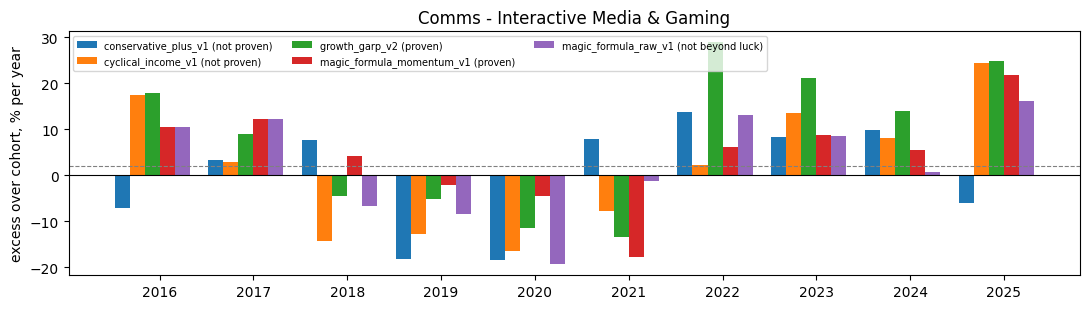

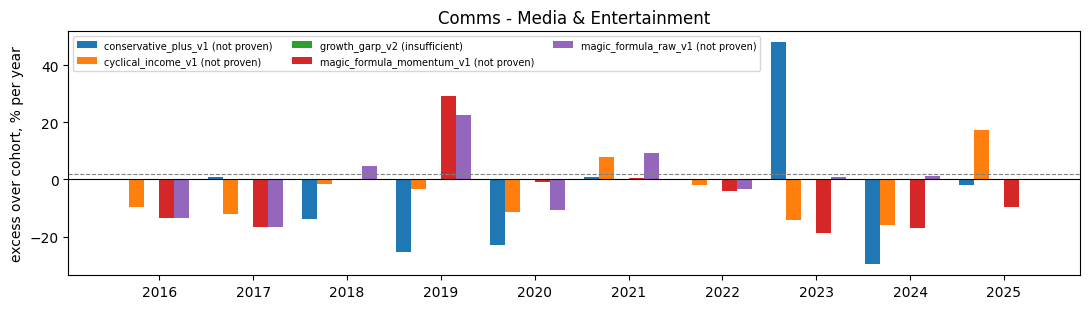

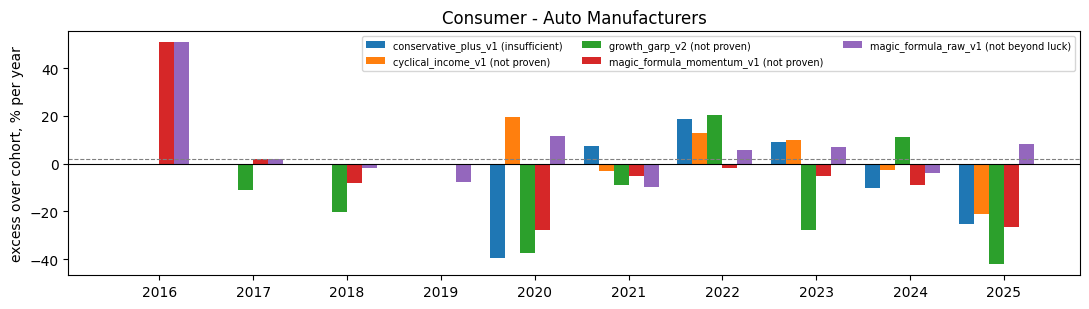

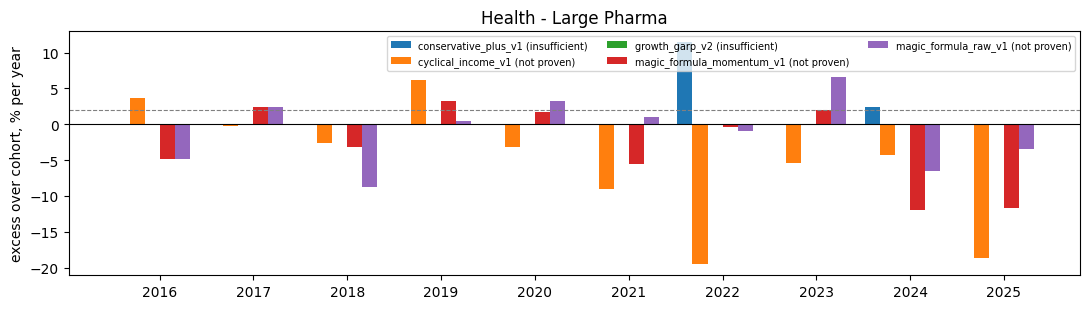

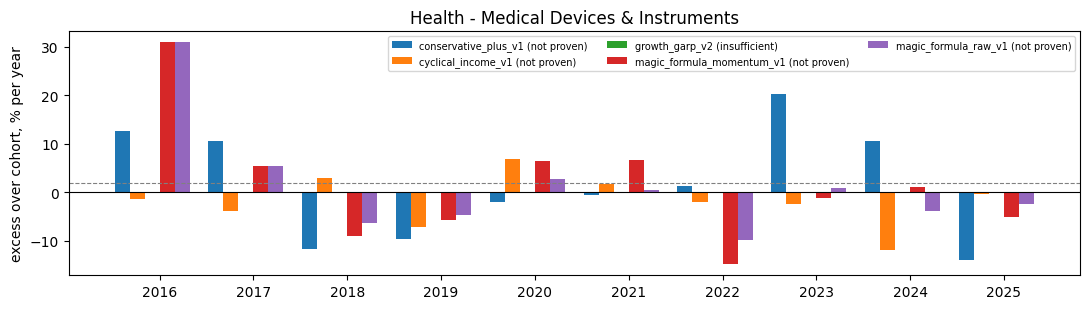

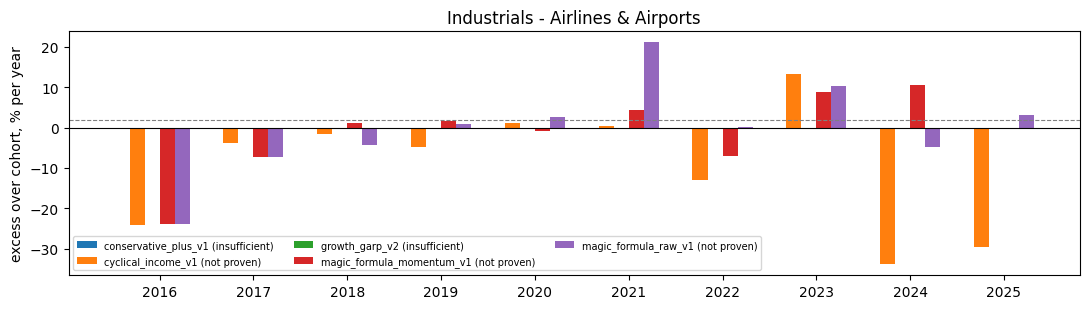

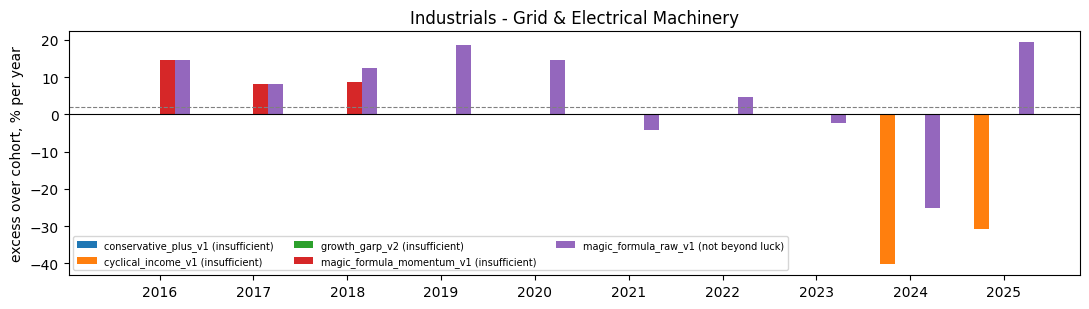

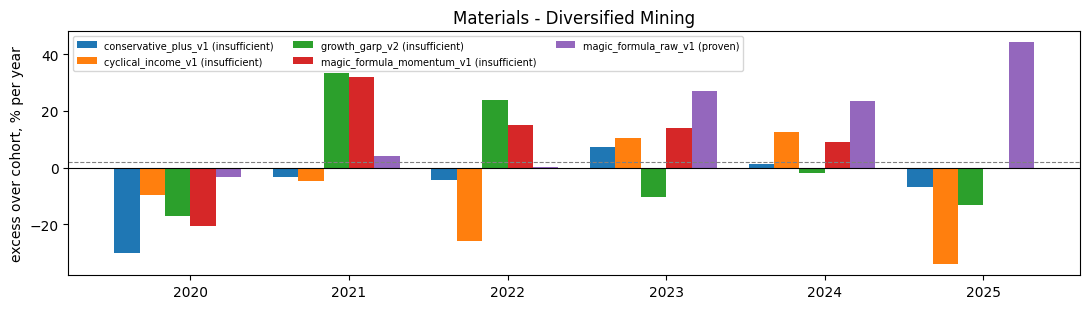

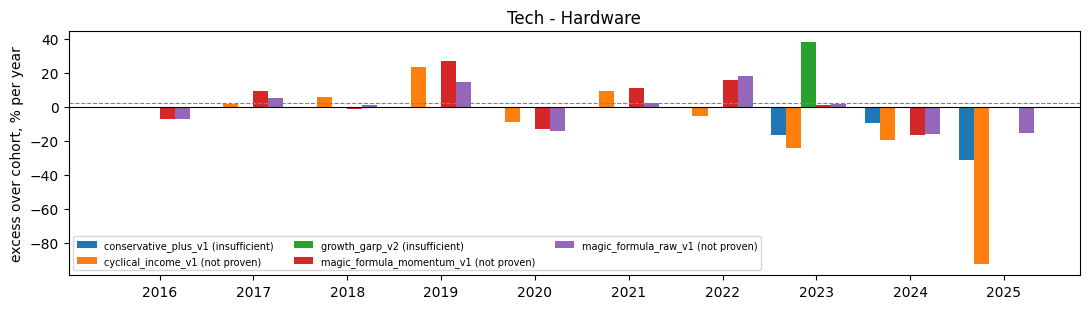

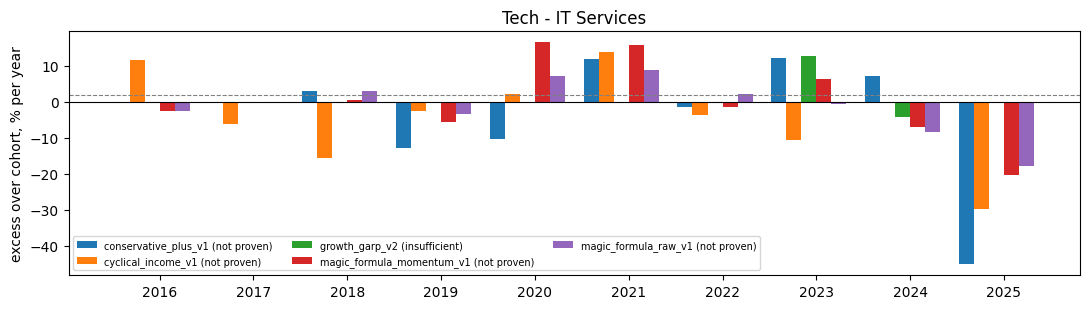

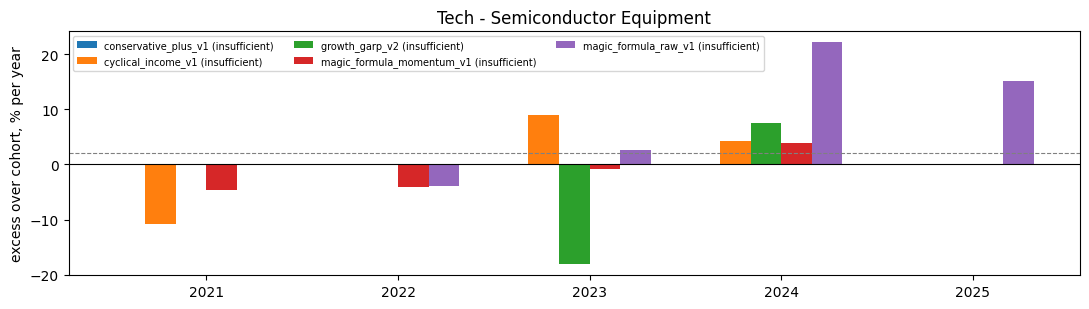

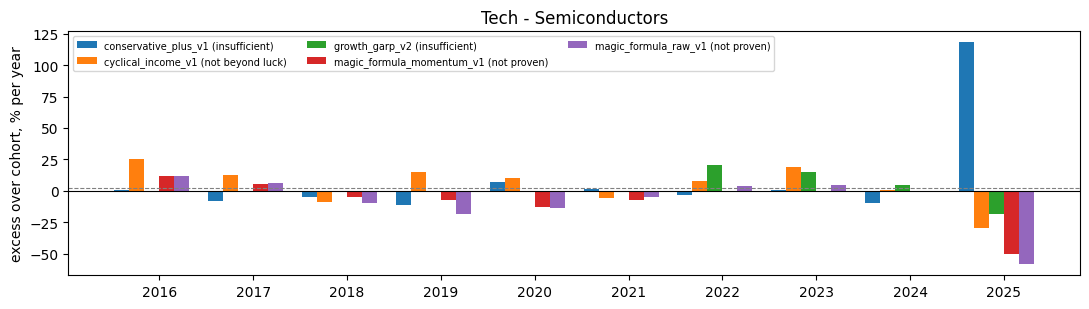

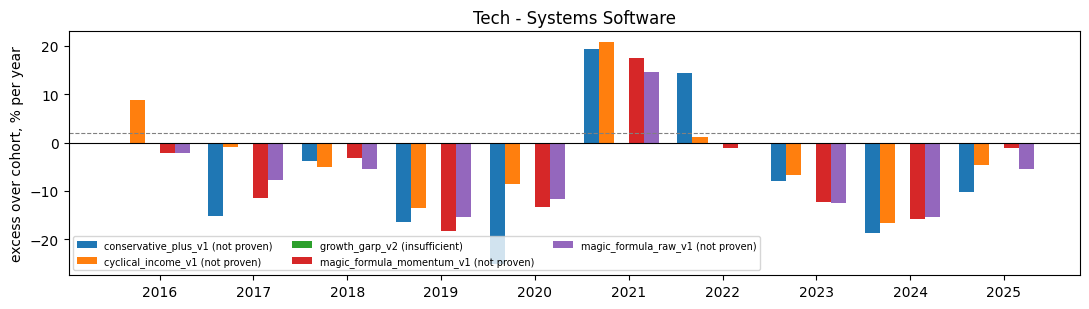

In [7]:
#@title 7. Chart: yearly excess per cohort (one panel per cohort, one bar colour per lens)
import matplotlib.pyplot as plt
from aristos_council.backtest import from_csv
by_cohort = {}
for path in sorted(glob.glob(f"{OUT}/*/*.csv")):
    r = from_csv(path); by_cohort.setdefault(r.cohort, []).append(r)
for cohort, rs in by_cohort.items():
    years = sorted({y for r in rs for y in r.year_excess})
    fig, ax = plt.subplots(figsize=(11, 3.2)); width = 0.8 / max(1, len(rs))
    for i, r in enumerate(rs):
        vals = [100 * r.year_excess.get(y, 0) for y in years]
        ax.bar([x + i * width for x in range(len(years))], vals, width, label=f"{r.lens_id} ({verdict(r)})")
    ax.axhline(0, color="black", lw=0.8); ax.axhline(2, color="grey", lw=0.8, ls="--")
    ax.set_xticks([x + 0.4 for x in range(len(years))]); ax.set_xticklabels(years)
    ax.set_ylabel("excess over cohort, % per year"); ax.set_title(cohort); ax.legend(fontsize=7, ncol=3)
    plt.tight_layout(); plt.show()

In [8]:
#@title 8. Pack the results for the repo
import shutil
zip_path = shutil.make_archive(f"{DRIVE}/backtests_export", "zip", OUT)
print("zipped to", zip_path)
print("On your PC: unzip it into the repo folder as backtests\\ (so backtests\\<cohort>\\<lens>.csv), then commit.")

zipped to /content/drive/MyDrive/aristos/backtests_export.zip
On your PC: unzip it into the repo folder as backtests\ (so backtests\<cohort>\<lens>.csv), then commit.
